### 로지스틱회귀
- 모델의 이름은 회귀 모델이지만 결과는 분류로 사용
- 0과 1 사이의 값(실수)을 예측하여 0.5보다 큰 경우 1 출력 작은 경우는 0 출력 
- 종속 변수가 범주형인 경우 적용하는 회귀 분석 방식
- 종속 변수 y를 직접 모델링 하지 않고 y가 특정 범주에 속하는 확률을 모델링

- parameter
    - penalty
        - 기본값  : 'l2'
        - 'l1' : Lasso
        - 'l2' : Ridge
        - 'elasricnet' : ElasticNet
        - None : 규제 없음(선형 회귀)
    - C
        - 기본값 : 1.0
        - 규제 강도의 역수 
            - 작으수록 규제 강도 up(과적합 방지)
            - 클수록 규제 강도 down(유연)
    - class_weight
        - 기본값 : None
        - 클래스의 불균형을 처리 
            - 'balanced' : 클래스의 빈도에 반비례하게 가중치를 부여 
            - dict형 데이터 : {클래스명 : 가중치, ...} -> 특정 클래스에 가중치를 선택하여 부여
    - solver
        - 기본값 : 'lbfgs'
        - 최적의 알고리즘 선택 ( 데이터의 크기 , 규제 방식 )
            - 'lbfgs' : 다중 클래스를 지원 빠르고 안정적,  L2 / None 지원
            - 'liblinear' :  적은 데이터, L1 / L2 지원
            - 'saga' : 대규모 데이터, L1 / L2 / ElasicNet 지원
            - 'newton_cg', 'sag' : 대규모 지원, L2 /  None 지원
    - multi_class
        - 기본값 : 'auto'
        - 다중 클래스의 처리 방식 
            - 'ovr'(One vs Rest) : 2진분류를 반복 작업 
            - 'multinomial' : (softmax 기반, solver 제한)
            - 'auto' : solver와 데이터의 크기를 기반으로 자동 설정 
    - l1_ratio
        - 기본값 : None
        - ElasticNet 에서만 사용이 가능
    - dual 
        - 기본값 : False
        - solver의 값이 'liblinear'인 경우 사용
        - 데이터의 개수가 적은 경우 사용
        - 쌍대문제를 생성하여 해답을 내는 과정을 사용할것인가?
- 속성 
    - coef_ 
        - 회귀 계수 출력 
    - intercept_
        - y절편 출력 
    - classes_
        - 학습이 된 클래스의 목록
- 메서드 
    - decision_function(x)
        - 클래스 별 점수 
    - predict_proba(x)
        - 클래스 별 예측 확률
    - predict_log_proba(x)
        - 클래스 별 예측 로그 확률
    - score(x, y)
        - 회귀 모델은 score()의 결과가 r2score가 나오지만 로지스틱은 정확도를 출력

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

import warnings

In [2]:
# 경고 메시지 출력을 필터 
warnings.filterwarnings('ignore')

In [3]:
body = pd.read_csv("../data/bodyPerformance.csv")
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [4]:
body.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


- age
    - 나이 
- gender 
    - 성별 ( 문자열 데이터 )
- height_cm                
    - 키
- weight_kg                
    - 몸무게
- body fat_%
    - 체지방률
- diastolic                
    - 이완기 혈압
- systolic                 
    - 수출기 혈압
- gripForce                
    - 악력
- sit and bend forward_cm
    - 앉아 윗몸 앞으로 굽히기
- sit-ups counts
    - 윗몸 일으키기
- broad jump_cm
    - 제자리 멀리뛰기

In [5]:
body.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [6]:
# gender 컬럼 문자들을 숫자형태로 변환 
body['gender'].unique()

array(['M', 'F'], dtype=object)

In [7]:
body['gender'].value_counts()

gender
M    8467
F    4926
Name: count, dtype: int64

In [ ]:
# map 함수 활용 
body['gender'].map(
    lambda x : 0 if x == 'M' else 1
)

In [ ]:
body['gender'].map(
    {
        'M' : 0, 
        'F' : 1
    }
)

In [ ]:
# replace() 함수를 활용
body['gender'].replace('M', 0).replace('F', 1)

In [17]:
df = pd.get_dummies(body, columns=['gender'], drop_first=True)

In [19]:
# numpy 활용하는 방법 
np.where(
    body['gender'] == 'M', 0, 1
)

array([0, 0, 0, ..., 0, 1, 0], shape=(13393,))

In [20]:
# 분류 모델을 사용할때 target의 데이터들도 숫자형태로 변환 
df['class'].value_counts()

class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64

In [21]:
# class에서 A는 1 그외의 값들은 0으로 변환 
df['class_1'] = np.where(
    df['class'] == 'A', 1, 0
)

In [22]:
df['class_1'].value_counts()

class_1
0    10045
1     3348
Name: count, dtype: int64

In [23]:
flag = df['sit and bend forward_cm'] > 35
df.loc[flag, ]

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,gender_M,class_1
2657,33.0,165.6,60.40,17.8,81.0,127.0,38.6,213.0,53.0,244.0,B,True,0
3355,45.0,164.4,64.40,24.3,96.0,142.0,38.5,185.0,44.0,223.0,A,True,1
3718,24.0,170.1,72.68,21.2,78.0,130.0,39.9,35.2,43.0,295.0,C,True,0
4203,46.0,164.4,63.60,23.4,70.0,115.0,36.0,42.0,42.0,210.0,A,True,1
4438,59.0,175.4,68.10,21.3,74.0,122.0,36.2,40.0,40.0,174.0,B,True,0
6161,51.0,162.2,58.20,25.1,79.0,131.0,27.2,35.2,25.0,134.0,D,False,0
6306,22.0,160.5,50.80,17.0,57.0,107.0,30.2,35.2,46.0,181.0,A,False,1
7797,24.0,168.3,61.30,24.5,72.0,110.0,30.1,35.2,39.0,182.0,C,False,0
8905,52.0,166.3,74.30,26.0,79.0,131.0,47.1,40.0,40.0,194.0,B,True,0
11794,41.0,166.5,56.50,27.2,82.0,135.0,25.7,35.2,32.0,174.0,A,False,1


In [24]:
# 독립 변수 종속 변수 데이터를 분할 
x = df.drop(['class', 'class_1'], axis=1)
y = df['class_1']

In [25]:
# train, test 셋으로 데이터 분할 
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

In [26]:
# 모델 생성 
logR = LogisticRegression()

In [27]:
logR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
# 예측 확률 데이터를 확인 
proba = pd.DataFrame(
    logR.predict_proba(X_train)
)
# 클래스별 점수 ( 분류의 대한 확신의 점수 )
cs = pd.DataFrame(
    logR.decision_function(X_train)
)
# proba, cs 데이터 프레임을 단순 열결합 
df2 = pd.concat( [proba, cs], axis=1 )

df2

,0,1,0
0,0.856729,0.143271,-1.788382
1,0.424180,0.575820,0.305636
2,0.998330,0.001670,-6.393513
3,0.968892,0.031108,-3.438676
4,0.631473,0.368527,-0.538540
...,...,...,...
9370,0.227643,0.772357,1.221666
9371,0.999971,0.000029,-10.455851
9372,0.896985,0.103015,-2.164165
9373,0.989412,0.010588,-4.537419


In [29]:
df2.columns = ['Not A', 'A', 'decision_function']
df2

,Not A,A,decision_function
0,0.856729,0.143271,-1.788382
1,0.424180,0.575820,0.305636
2,0.998330,0.001670,-6.393513
3,0.968892,0.031108,-3.438676
4,0.631473,0.368527,-0.538540
...,...,...,...
9370,0.227643,0.772357,1.221666
9371,0.999971,0.000029,-10.455851
9372,0.896985,0.103015,-2.164165
9373,0.989412,0.010588,-4.537419


In [31]:
df2.sort_values('decision_function', inplace=True)
df2.reset_index(drop=True, inplace=True)
df2

,Not A,A,decision_function
0,1.000000e+00,4.947547e-09,-19.124374
1,1.000000e+00,1.864949e-08,-17.797447
2,1.000000e+00,3.197806e-08,-17.258216
3,1.000000e+00,4.145663e-08,-16.998618
4,9.999999e-01,5.919798e-08,-16.642378
...,...,...,...
9370,2.048363e-03,9.979516e-01,6.188664
9371,1.877881e-03,9.981221e-01,6.275732
9372,1.523423e-03,9.984766e-01,6.485271
9373,1.554312e-15,1.000000e+00,34.118975


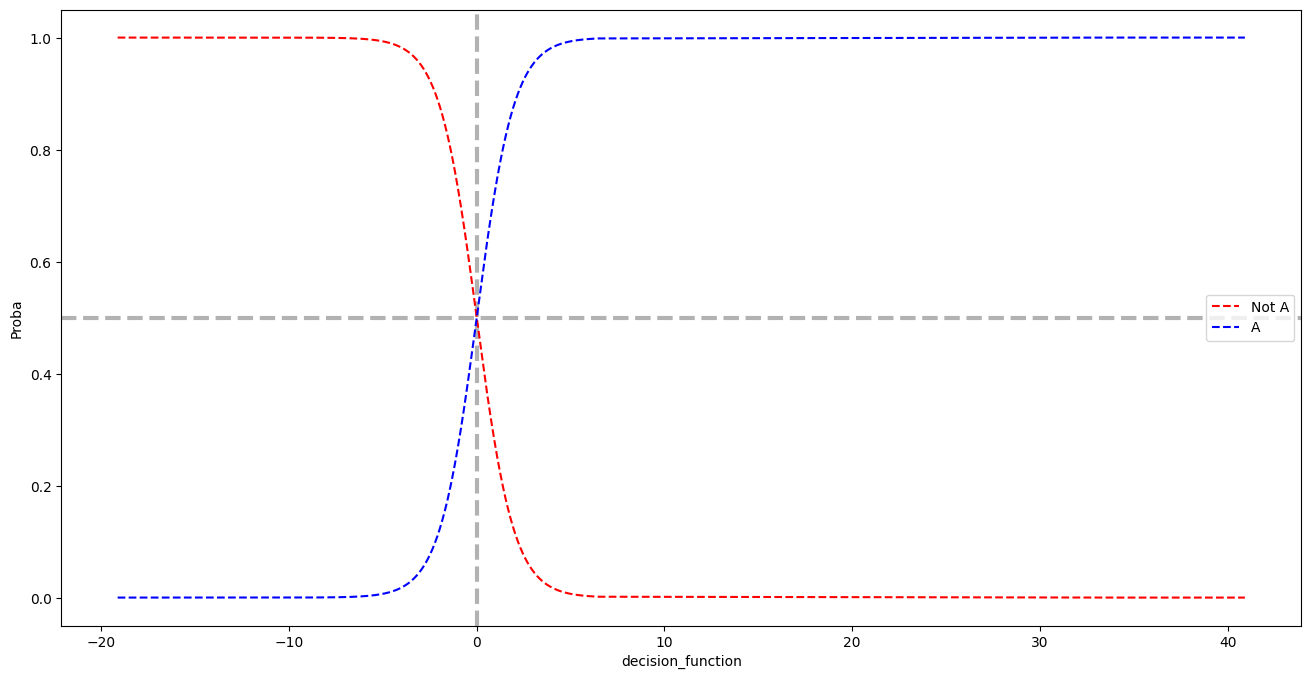

In [35]:
# 그래프 시각화 
plt.figure(figsize = (16, 8))

# 보조선 추가 
plt.axhline(y = 0.5, linestyle = '--', color = 'black', linewidth = 3, alpha = 0.3)
plt.axvline(x = 0, linestyle = '--', color = 'black', linewidth = 3, alpha = 0.3)

plt.plot(df2['decision_function'], df2['Not A'], 'r--', label = 'Not A')
plt.plot(df2['decision_function'], df2['A'], 'b--', label = 'A')

plt.legend()
plt.xlabel('decision_function')
plt.ylabel('Proba')

plt.show()

- 혼동행렬
    - 이진 분류의 예측 오류가 얼마인가 어떠한 유형의 오류가 발생하는지를 나타내는 지표
        - TN : 예측이 Negative(0), 실제 값 Negative(0)
        - FP : 예측이 Positive(1), 실제 값 Negative(0)
        - FN : 예측이 Negative(0), 실제 값 Positive(1)
        - TP : 예측이 Positive(1), 실제 값 Positive(1)
- 정확도 
    - 실제 데이터와 예측 데이터가 얼마나 같은가?
    - TN + TP / TN + FP + FN + TP
- 정밀도 
    - 양성 예측도 
    - TP / TP + FP
    - 스팸 메일인지 아닌지 
- 재현율
    - TP / TP + FN
    - 암 환단 진단 , 신용카드 사기 탐지
- F1_Score
    - 정밀도와 재현율을 결합한 분류 성능 지표
    - 어느 한쪽에 치우치지 않고 적절하게 조화를 이루었을때 높은 수치를 나타냄 
    - (2*TP) / (2*TP + FP + FN)

In [36]:
# 학습된 모델을 이용하여 예측 
pred = logR.predict(X_test)

In [37]:
cm = confusion_matrix(y_test, pred)
acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

In [38]:
print(cm)

[[2749  265]
 [ 388  616]]


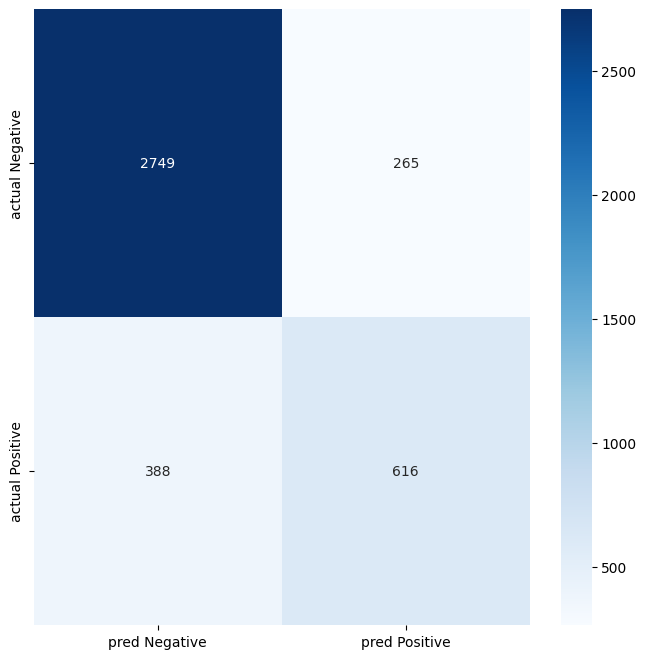

In [39]:
# 혼동 행렬 그래프 시각화
plt.figure(figsize=(8, 8))

sns.heatmap(
    cm, annot = True, cmap='Blues', fmt='d', 
    xticklabels= ['pred Negative', 'pred Positive'], 
    yticklabels= ['actual Negative', 'actual Positive']
)
plt.show()

In [40]:
print('정확도 : ', round(acc, 2))
print('정밀도 : ', round(prc, 2))
print('재현율 : ', round(rcll, 2))
print('f1 : ', round(f1, 2))

정확도 :  0.84
정밀도 :  0.7
재현율 :  0.61
f1 :  0.65


In [41]:
# 데이터의 불균형을 해결 해보자 
# 샘플링 기법을 이용하여 데이터의 균형을 맞춘다. 
# 모델 생성 시 불균형한 데이터들에 가중치를 특별 부여 
logR2 = LogisticRegression(class_weight='balanced')

In [42]:
logR2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [43]:
pred_2 = logR2.predict(X_test)

In [44]:
acc2 = accuracy_score(y_test, pred_2)
prc2 = precision_score(y_test, pred_2)
rcll2 = recall_score(y_test, pred_2)
f1_2 = f1_score(y_test, pred_2)

In [45]:
print("정확도 : ", round(acc, 2) ,round(acc2, 2))
print('정밀도 : ', round(prc, 2), round(prc2, 2))
print('재현율 : ', round(rcll, 2), round(rcll2, 2))
print('f1 : ', round(f1, 2), round(f1_2, 2))

정확도 :  0.84 0.81
정밀도 :  0.7 0.59
재현율 :  0.61 0.84
f1 :  0.65 0.69


In [47]:
# 극단치의 데이터들을 수정 
# 극단치를 제거 
from outlier import outlier_iqr

In [ ]:
outlier_drop_df, outlier_dict = outlier_iqr(df, *df.drop('class_1', axis=1).columns, drop=True)

In [56]:
len(body)

13393

In [57]:
len(outlier_drop_df)

12634

In [58]:
outlier_drop_df['class_1'].value_counts()

class_1
0    9316
1    3318
Name: count, dtype: int64

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    outlier_drop_df.drop(['class', 'class_1'], axis=1), 
    outlier_drop_df['class_1'], 
    test_size=0.3, 
    stratify=outlier_drop_df['class_1']
)

In [60]:
logR2.fit(X_train, y_train)

pred_3 = logR2.predict(X_test)

acc_3 = accuracy_score(y_test, pred_3)
prc_3 = precision_score(y_test, pred_3)
rcll_3 = recall_score(y_test, pred_3)
f1_3 = f1_score(y_test, pred_3)

In [61]:
print("정확도 : ",  round(acc_3, 2))
print("정밀도 : ", round(prc_3, 2))
print("재현율 : ", round(rcll_3, 2))
print('f1 : ', round(f1_3, 2))

정확도 :  0.81
정밀도 :  0.6
재현율 :  0.85
f1 :  0.71


In [62]:
# 데이터 불균형 문제를 해결하기 위해 샘플링 기법 -> class_weight는 제외

# 언더 샘플링 , SMOTE 사용
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [63]:
# fit_resample() -> 독립 변수, 종속 변수 대입 
undersample = RandomUnderSampler(sampling_strategy=1)
x = df.drop(['class', 'class_1'], axis=1)
y = df['class_1']

x_under, y_under = undersample.fit_resample(x, y)

In [64]:
len(x_under)

6696

In [72]:
def logR_funciton(x, y, weight = None):
    # x : 독립변수
    # y ; 종속변수
    # weigth : 모델에서 class_weight의 인자 값
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size = 0.3, random_state=42, stratify=y
    )

    # 모델 생성 
    model = LogisticRegression(class_weight= weight)

    # 학습 
    model.fit(X_train, y_train)

    # 예측
    pred = model.predict(X_test)

    # 성능 지표
    acc = accuracy_score(y_test, pred)
    prc = precision_score(y_test, pred, average='macro')
    rcll = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')

    print("정확도 : ", round(acc, 2))
    print("정밀도 : ", round(prc, 2))
    print('재현율 : ', round(rcll, 2) )
    print('f1 : ', round(f1, 2))
    return pred

In [66]:
under_pred = logR_funciton(x_under, y_under)

정확도 :  0.85
정밀도 :  0.83
재현율 :  0.86
f1 :  0.85


In [67]:
smote = SMOTE(sampling_strategy=1)

x_over, y_over = smote.fit_resample(x, y)

len(x_over)

20090

In [69]:
over_pred = logR_funciton(x_over, y_over)

정확도 :  0.85
정밀도 :  0.83
재현율 :  0.88
f1 :  0.85


### 연습 문제 
- body 데이터에서 성별 컬럼을 0, 1로 변환
- class 컬럼의 데이터들은 A는 1 B는 2 C는 3 D는 4 변경
- 극단치데이터를 경계 값들로 대체 
- 로지스틱 회귀를 이용하여 혼동행렬, 나머지 성능 지표를 확인 

In [74]:
body['gender'] = body['gender'].map(
    {
        'M' : 0, 
        'F' : 1
    }
)

In [ ]:
body['class'].map(
    lambda x : 1 if x == 'A' else 2 if x == 'B' else 3 if x == 'C' else 4
)

In [78]:
body['class'] = body['class'].map(
    {
        'A' : 1, 
        'B' : 2, 
        'C' : 3, 
        'D' : 4
    }
)

In [89]:
cols = body.drop('class', axis=1).columns

outlier_df, whis_dict = outlier_iqr(body, *cols) 


                지정된 컬럼의 이름 : age, 
                상단의 경계 값 : 82.5, 
                하단의 경계 값 : -9.5
            
 상단의 경계를 벗어나는 데이터의 개수 : 0 하단의 경계를 벗어나는 데이터의 개수 : 0 

                지정된 컬럼의 이름 : gender, 
                상단의 경계 값 : 2.5, 
                하단의 경계 값 : -1.5
            
 상단의 경계를 벗어나는 데이터의 개수 : 0 하단의 경계를 벗어나는 데이터의 개수 : 0 

                지정된 컬럼의 이름 : height_cm, 
                상단의 경계 값 : 193.40000000000003, 
                하단의 경계 값 : 143.8
            
 상단의 경계를 벗어나는 데이터의 개수 : 1 하단의 경계를 벗어나는 데이터의 개수 : 9 

                지정된 컬럼의 이름 : weight_kg, 
                상단의 경계 값 : 100.94999999999999, 
                하단의 경계 값 : 32.55000000000001
            
 상단의 경계를 벗어나는 데이터의 개수 : 81 하단의 경계를 벗어나는 데이터의 개수 : 2 

                지정된 컬럼의 이름 : body fat_%, 
                상단의 경계 값 : 43.0, 
                하단의 경계 값 : 3.0
            
 상단의 경계를 벗어나는 데이터의 개수 : 77 하단의 경계를 벗어나는 데이터의 개수 : 0 

                지정된 컬럼의 이름 : diastolic, 
                상단의 경계 값 : 108.5, 
                하단의 경계 값

In [90]:
outlier_df.shape

(13393, 12)

In [91]:
outlier_df['class'].value_counts()

class
3    3349
4    3349
1    3348
2    3347
Name: count, dtype: int64

In [92]:
x = outlier_df.drop('class', axis=1)
y = outlier_df['class']

pred = logR_funciton(x, y)

정확도 :  0.6
정밀도 :  0.6
재현율 :  0.6
f1 :  0.6


- 정밀도, 재현율, f1score에서는 다중 분류 모델에서는 일반적인 계산 x (error 발생)
    - aveage
        - 'macro'
            - 다중 분류에서 각각의 점수들이 생성이 되면 점수들의 평균을 출력
            - a : 90점, b : 30점, c : 50점, d : 10점
            - 점수들의 평균 : 45점
            - 모든 클래스의 점수를 차별없이 똑같이 잘 맞추는 모델 
        - 'wighted'
            - 각 클래스별 가중치(비율)를 생성하여 계산 
            - a : 100/150 90점, b : 30 / 150, 30점, c : 20 / 150 20점
            - (90 * 100/150) + (30 * 30 / 150) + (20 * 20 / 150)
        - 'micro'
            - 혼동행렬의 모든 값들은 합산에서 점수를 생성 
            - 이진 분류에서 정확도 똑같은 값들이 생성


In [93]:
datas = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

In [95]:
datas[3]

11398    3
11041    2
5262     2
3386     1
9410     2
        ..
3902     4
11139    4
8182     1
13       3
10       1
Name: class, Length: 4018, dtype: int64

In [96]:
cm = confusion_matrix(datas[3], pred)

In [97]:
cm

array([[739, 239,  26,   0],
       [266, 415, 284,  39],
       [120, 192, 492, 201],
       [ 27,  45, 162, 771]])

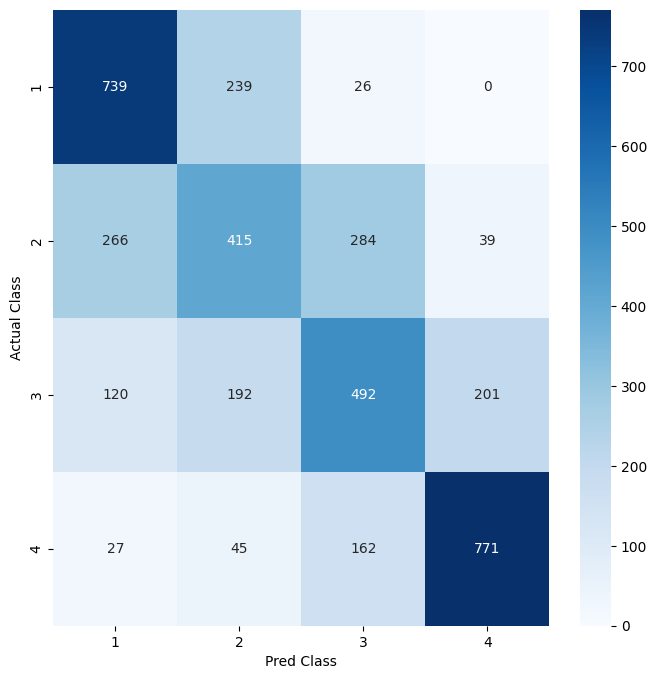

In [99]:
plt.figure(figsize=(8, 8))

sns.heatmap(
    cm, 
    annot=True, 
    cmap = "Blues", 
    fmt = 'd', 
    xticklabels=[1, 2, 3, 4], 
    yticklabels=[1, 2, 3, 4]
)
plt.ylabel('Actual Class')
plt.xlabel('Pred Class')
plt.show()